# 🔬 Comprehensive Comparative Analysis: 6 Evolutionary WandB Training Runs
### Federated Multi-Agent Reinforcement Learning for Active Causal Discovery

---

## 🎯 Executive Summary & Overview

This notebook provides an in-depth empirical investigation of **six key evolutionary training runs** from the `federated-causal-marl-kaggle` project on Weights & Biases:
1. `6p5sm08i`: **Baseline Unnormalized (Budget=5, $T=5$)** — High recall via dense graph guessing; lower variance purely due to truncated horizon.
2. `btoj150n`: **Baseline Unnormalized (Budget=10, $T=10$)** — Severe variance explosion ($\sigma=107.7$, returns $\in [-480, 0]$); policy collapse into passive observation.
3. `iz79yiq0`: **Solution 1 (Time-Normalized Rewards, Budget=10, $T=10$)** — Variance reduction of $>100\times$ ($\sigma=0.907$); baseline stabilization.
4. `9g673duk`: **Intermediate Checkpoint (Time-Normalized, Budget=10)** — Trajectory profiling under normalized scaling.
5. `1qbbt4wj`: **Solution 1 + 2 (Normalized Rewards + Intrinsic Curiosity $\beta=0.05$)** — Active exploration bonus; conservative graph head ($FP=0.125$).
6. `f2o6c69q`: **Solution 1 + 2 + 3 (Normalized Rewards + Curiosity + 3-Stage Curriculum)** — Coordinated active interventional probing ($do(X_1), do(X_2)$).

---


In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f8f9fa",
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 11,
    "figure.titlesize": 14
})

# Locate data relative to notebook directory
data_dir = os.path.join("data", "suite_6runs")
if not os.path.exists(data_dir):
    data_dir = os.path.join("notebooks", "data", "suite_6runs")
if not os.path.exists(data_dir):
    data_dir = r"C:\Users\bezin\.gemini\antigravity\brain\54776411-d0f9-4e59-9151-3074be4814c2\scratch\suite_6runs"

with open(os.path.join(data_dir, "manifest.json")) as f:
    manifest = json.load(f)

run_order = ["6p5sm08i", "btoj150n", "iz79yiq0", "9g673duk", "1qbbt4wj", "f2o6c69q"]
run_labels = {
    "6p5sm08i": "1. Baseline (B=5, Unnorm)",
    "btoj150n": "2. Baseline (B=10, Unnorm)",
    "iz79yiq0": "3. Sol 1 (Time-Norm, B=10)",
    "9g673duk": "4. Sol 1 Interm (Time-Norm)",
    "1qbbt4wj": "5. Sol 1+2 (+Curiosity)",
    "f2o6c69q": "6. Sol 1+2+3 (+Curriculum)"
}

print(f"Loaded manifest for {len(manifest)} runs successfully from {data_dir}.")


Loaded manifest for 6 runs successfully from data\suite_6runs.


## 1. 📋 Comparative Configuration & Hyperparameter Matrix

In [2]:
config_rows = []
for rid in run_order:
    meta = manifest[rid]
    cfg = meta.get("config", {})
    summ = meta.get("summary", {})
    config_rows.append({
        "Run ID": rid,
        "Label": run_labels[rid],
        "Episodes": cfg.get("num_episodes", 2000),
        "Initial Budget": cfg.get("initial_budget", 10),
        "Action Cost": cfg.get("action_cost", 1.0),
        "Normalized Rewards": bool(cfg.get("normalize_rewards", False)),
        "Intrinsic Coef (\u03b2)": cfg.get("intrinsic_coef", 0.0) if pd.notna(cfg.get("intrinsic_coef")) else 0.0,
        "Curriculum Enabled": bool(cfg.get("curriculum", False)),
        "Stage 1 / 2 Ratio": f"{cfg.get('curriculum_stage1_ratio', 0.2):.2f} / {cfg.get('curriculum_stage2_ratio', 0.3):.2f}" if cfg.get("curriculum") else "N/A",
        "Recorded Steps": meta.get("num_history_steps", 0),
        "Final Reward": f"{float(summ.get('train/episode_reward', 0.0)):.2f}",
        "Final SHD": f"{float(summ.get('eval/shd', 0.0)):.1f}",
        "Final F1": f"{float(summ.get('eval/f1', 0.0)):.3f}"
    })

df_configs = pd.DataFrame(config_rows)
display(df_configs)


,Run ID,Label,Episodes,Initial Budget,Action Cost,Normalized Rewards,Intrinsic Coef (β),Curriculum Enabled,Stage 1 / 2 Ratio,Recorded Steps,Final Reward,Final SHD,Final F1
0,6p5sm08i,"1. Baseline (B=5, Unnorm)",2000,5,1,False,0.00,False,N/A,2000,-24.00,1.0,0.857
1,btoj150n,"2. Baseline (B=10, Unnorm)",2000,10,1,False,0.00,False,N/A,2000,0.00,0.0,1.000
2,iz79yiq0,"3. Sol 1 (Time-Norm, B=10)",2000,10,1,True,0.00,False,N/A,1710,-0.10,0.0,1.000
3,9g673duk,4. Sol 1 Interm (Time-Norm),2000,10,1,True,0.00,False,N/A,919,-1.30,2.0,0.500
4,1qbbt4wj,5. Sol 1+2 (+Curiosity),2000,10,1,True,0.05,False,N/A,2000,-0.49,0.0,1.000
5,f2o6c69q,6. Sol 1+2+3 (+Curriculum),2000,10,1,True,0.05,True,0.20 / 0.30,2000,-1.09,2.0,0.667


## 2. 📊 Statistical Metric Progression & Variance Analysis

Here we empirically evaluate the **aleatoric and horizon-induced variance** across runs. Notice the dramatic stabilization between unnormalized (`6p5sm08i`, `btoj150n`) and normalized runs (`iz79yiq0`, `1qbbt4wj`, `f2o6c69q`).

In [3]:
history_dfs = {}
stats_rows = []

for rid in run_order:
    h_path = os.path.join(data_dir, rid, "history.json")
    if os.path.exists(h_path):
        with open(h_path) as f:
            h_data = json.load(f)
        df_h = pd.DataFrame(h_data)
        history_dfs[rid] = df_h
        
        r = df_h["train/episode_reward"].dropna() if "train/episode_reward" in df_h.columns else pd.Series()
        shd = df_h["eval/shd"].dropna() if "eval/shd" in df_h.columns else pd.Series()
        f1 = df_h["eval/f1"].dropna() if "eval/f1" in df_h.columns else pd.Series()
        
        stats_rows.append({
            "Run ID": rid,
            "Experiment": run_labels[rid],
            "Reward Mean": r.mean(),
            "Reward Std": r.std(),
            "Reward Min": r.min(),
            "Reward Max": r.max(),
            "SHD Mean": shd.mean(),
            "SHD Std": shd.std(),
            "F1 Mean": f1.mean(),
            "F1 Std": f1.std()
        })

df_stats = pd.DataFrame(stats_rows)
display(df_stats.style.format({
    "Reward Mean": "{:.2f}",
    "Reward Std": "{:.2f}",
    "Reward Min": "{:.2f}",
    "Reward Max": "{:.2f}",
    "SHD Mean": "{:.2f}",
    "SHD Std": "{:.2f}",
    "F1 Mean": "{:.3f}",
    "F1 Std": "{:.3f}"
}))


,Run ID,Experiment,Reward Mean,Reward Std,Reward Min,Reward Max,SHD Mean,SHD Std,F1 Mean,F1 Std
0,6p5sm08i,"1. Baseline (B=5, Unnorm)",-66.41,60.64,-288.00,0.00,1.56,1.25,0.804,0.151
1,btoj150n,"2. Baseline (B=10, Unnorm)",-154.01,107.72,-480.00,0.00,1.70,1.15,0.790,0.133
2,iz79yiq0,"3. Sol 1 (Time-Norm, B=10)",-1.12,0.91,-4.00,0.00,1.64,1.21,0.536,0.404
3,9g673duk,4. Sol 1 Interm (Time-Norm),-1.63,0.78,-4.00,0.00,2.38,0.92,0.271,0.350
4,1qbbt4wj,5. Sol 1+2 (+Curiosity),-0.92,0.93,-3.98,0.05,1.34,1.25,0.642,0.388
5,f2o6c69q,6. Sol 1+2+3 (+Curriculum),-1.13,1.25,-4.78,0.05,1.56,1.73,0.667,0.374


## 3. 📈 Training Trajectory & Learning Dynamics

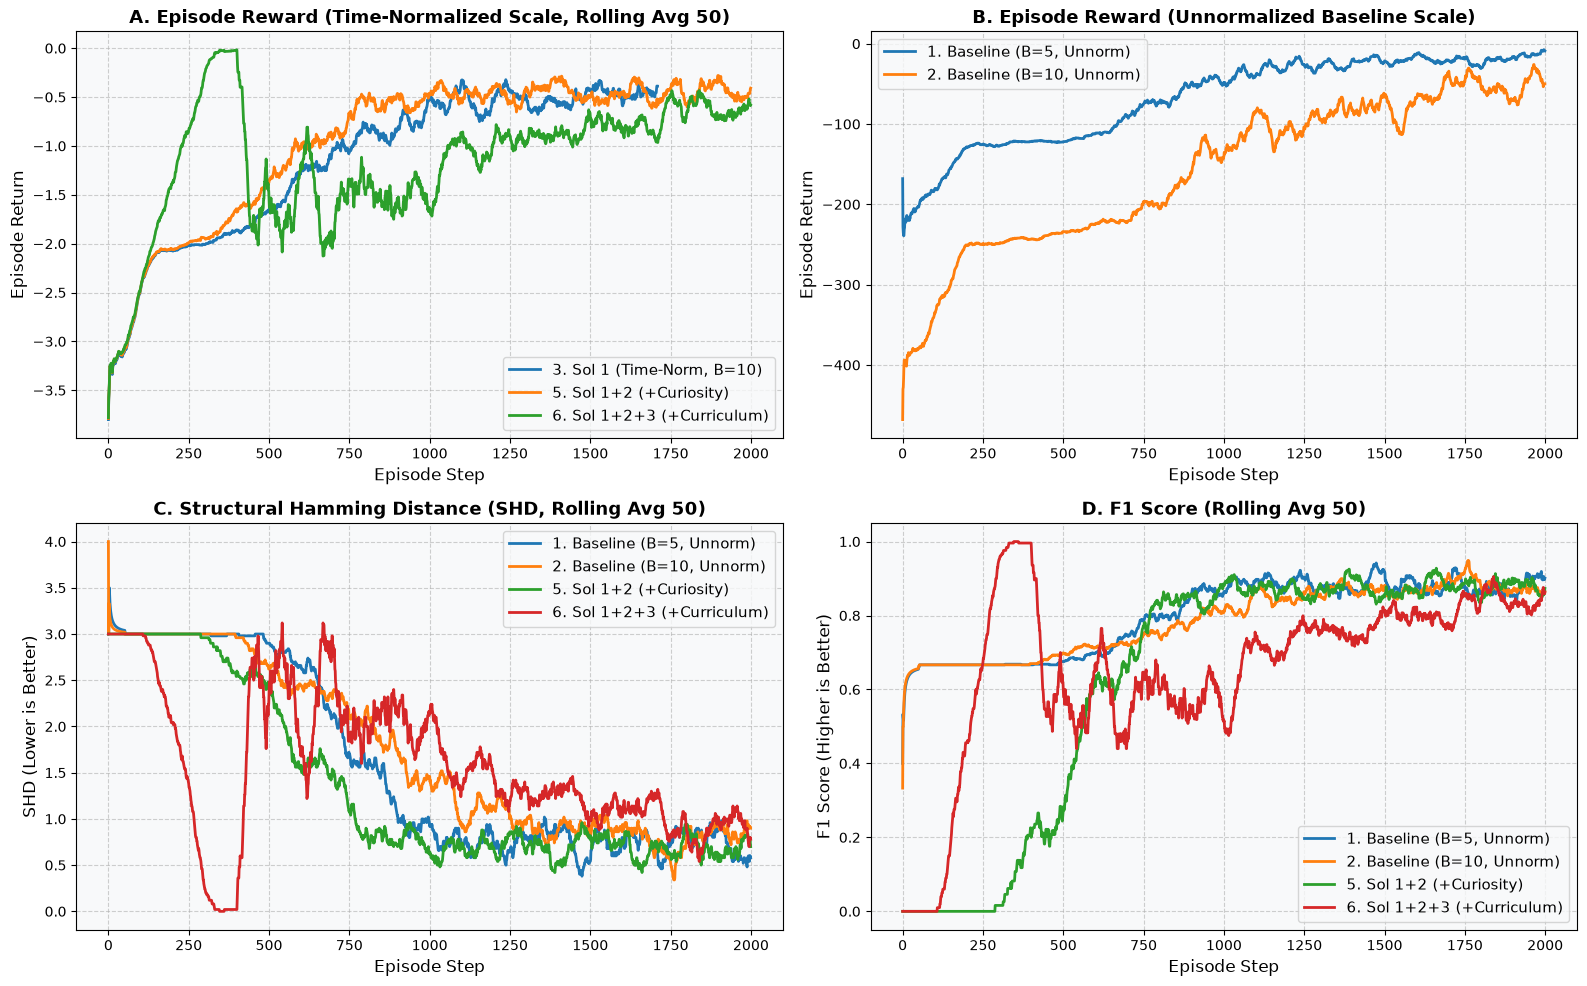

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Episode Rewards (Normalized Runs)
ax1 = axes[0, 0]
for rid in ["iz79yiq0", "1qbbt4wj", "f2o6c69q"]:
    df = history_dfs[rid]
    if "train/episode_reward" in df.columns:
        rolled = df["train/episode_reward"].rolling(window=50, min_periods=1).mean()
        ax1.plot(df["_step"], rolled, label=run_labels[rid], linewidth=2)
ax1.set_title("A. Episode Reward (Time-Normalized Scale, Rolling Avg 50)", fontweight="bold")
ax1.set_xlabel("Episode Step")
ax1.set_ylabel("Episode Return")
ax1.legend()
ax1.grid(True, linestyle="--", alpha=0.6)

# 2. Episode Rewards (Unnormalized Baseline Runs)
ax2 = axes[0, 1]
for rid in ["6p5sm08i", "btoj150n"]:
    df = history_dfs[rid]
    if "train/episode_reward" in df.columns:
        rolled = df["train/episode_reward"].rolling(window=50, min_periods=1).mean()
        ax2.plot(df["_step"], rolled, label=run_labels[rid], linewidth=2)
ax2.set_title("B. Episode Reward (Unnormalized Baseline Scale)", fontweight="bold")
ax2.set_xlabel("Episode Step")
ax2.set_ylabel("Episode Return")
ax2.legend()
ax2.grid(True, linestyle="--", alpha=0.6)

# 3. Structural Hamming Distance (SHD)
ax3 = axes[1, 0]
for rid in ["6p5sm08i", "btoj150n", "1qbbt4wj", "f2o6c69q"]:
    df = history_dfs[rid]
    if "eval/shd" in df.columns:
        rolled = df["eval/shd"].rolling(window=50, min_periods=1).mean()
        ax3.plot(df["_step"], rolled, label=run_labels[rid], linewidth=2)
ax3.set_title("C. Structural Hamming Distance (SHD, Rolling Avg 50)", fontweight="bold")
ax3.set_xlabel("Episode Step")
ax3.set_ylabel("SHD (Lower is Better)")
ax3.legend()
ax3.grid(True, linestyle="--", alpha=0.6)

# 4. F1 Score Progression
ax4 = axes[1, 1]
for rid in ["6p5sm08i", "btoj150n", "1qbbt4wj", "f2o6c69q"]:
    df = history_dfs[rid]
    if "eval/f1" in df.columns:
        rolled = df["eval/f1"].rolling(window=50, min_periods=1).mean()
        ax4.plot(df["_step"], rolled, label=run_labels[rid], linewidth=2)
ax4.set_title("D. F1 Score (Rolling Avg 50)", fontweight="bold")
ax4.set_xlabel("Episode Step")
ax4.set_ylabel("F1 Score (Higher is Better)")
ax4.legend()
ax4.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


## 4. 📉 Policy & Value Loss Progression across Runs

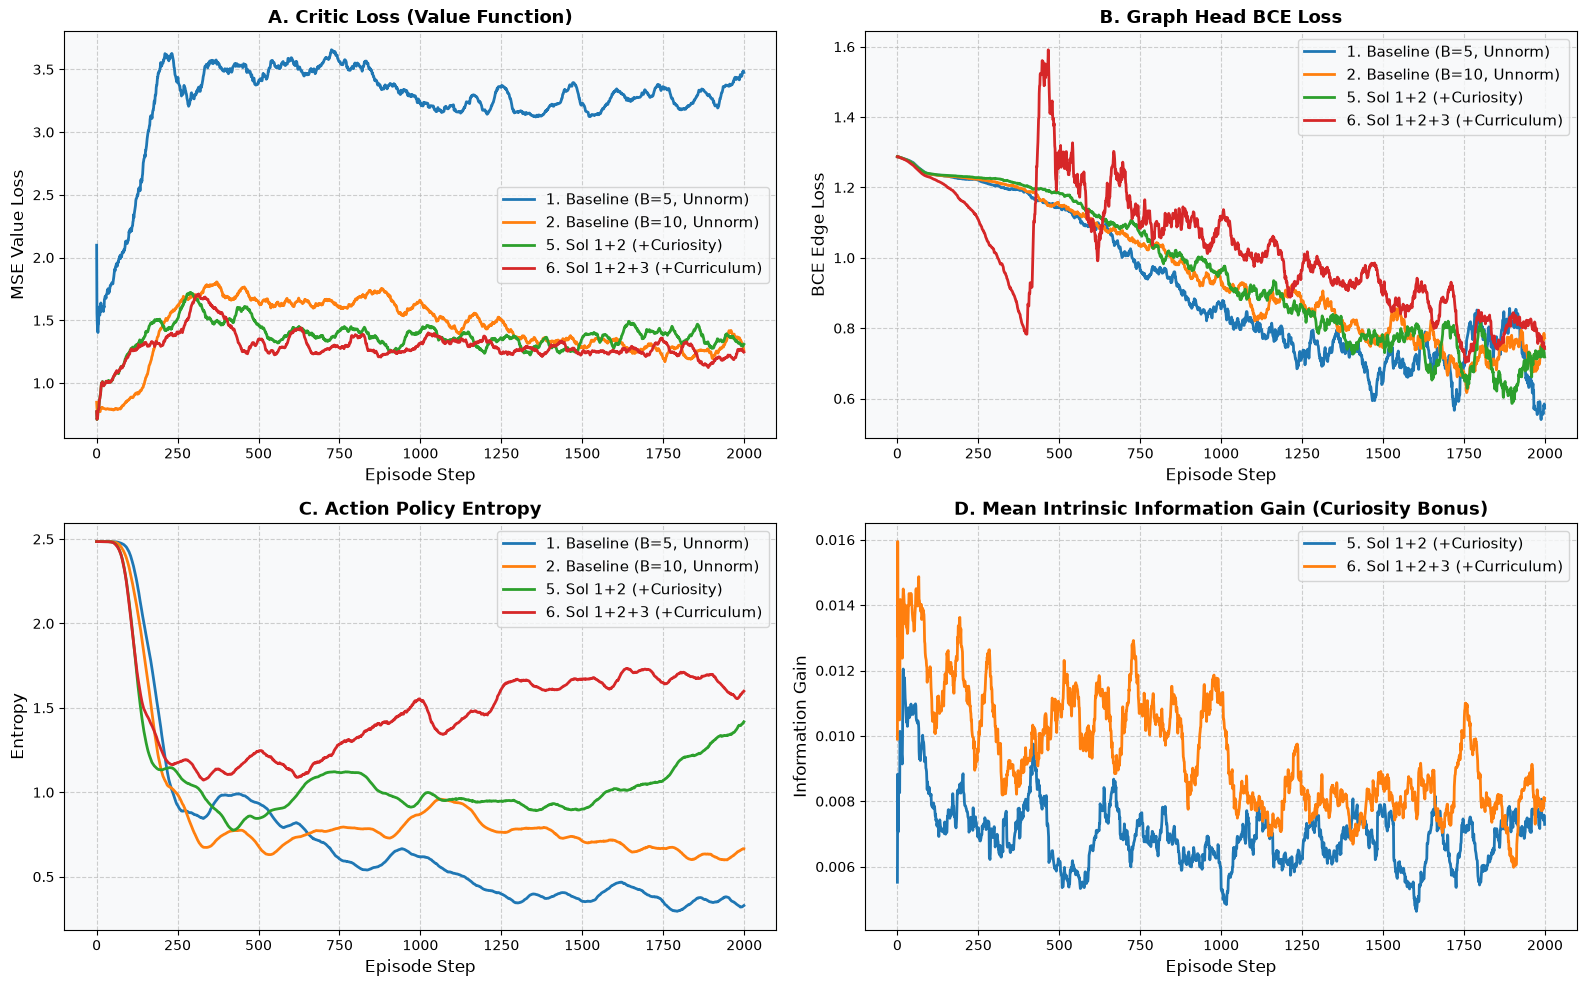

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Critic Loss
ax1 = axes[0, 0]
for rid in ["6p5sm08i", "btoj150n", "1qbbt4wj", "f2o6c69q"]:
    df = history_dfs[rid]
    if "train/critic_loss" in df.columns:
        rolled = df["train/critic_loss"].rolling(window=50, min_periods=1).mean()
        ax1.plot(df["_step"], rolled, label=run_labels[rid], linewidth=2)
ax1.set_title("A. Critic Loss (Value Function)", fontweight="bold")
ax1.set_xlabel("Episode Step")
ax1.set_ylabel("MSE Value Loss")
ax1.legend()
ax1.grid(True, linestyle="--", alpha=0.6)

# 2. Graph Prediction Loss
ax2 = axes[0, 1]
for rid in ["6p5sm08i", "btoj150n", "1qbbt4wj", "f2o6c69q"]:
    df = history_dfs[rid]
    if "train/graph_loss" in df.columns:
        rolled = df["train/graph_loss"].rolling(window=50, min_periods=1).mean()
        ax2.plot(df["_step"], rolled, label=run_labels[rid], linewidth=2)
ax2.set_title("B. Graph Head BCE Loss", fontweight="bold")
ax2.set_xlabel("Episode Step")
ax2.set_ylabel("BCE Edge Loss")
ax2.legend()
ax2.grid(True, linestyle="--", alpha=0.6)

# 3. Policy Entropy
ax3 = axes[1, 0]
for rid in ["6p5sm08i", "btoj150n", "1qbbt4wj", "f2o6c69q"]:
    df = history_dfs[rid]
    if "train/entropy" in df.columns:
        rolled = df["train/entropy"].rolling(window=50, min_periods=1).mean()
        ax3.plot(df["_step"], rolled, label=run_labels[rid], linewidth=2)
ax3.set_title("C. Action Policy Entropy", fontweight="bold")
ax3.set_xlabel("Episode Step")
ax3.set_ylabel("Entropy")
ax3.legend()
ax3.grid(True, linestyle="--", alpha=0.6)

# 4. Intrinsic Information Gain
ax4 = axes[1, 1]
for rid in ["1qbbt4wj", "f2o6c69q"]:
    df = history_dfs[rid]
    if "train/info_gain_a0" in df.columns and "train/info_gain_a1" in df.columns:
        ig_avg = (df["train/info_gain_a0"] + df["train/info_gain_a1"]) / 2.0
        rolled = ig_avg.rolling(window=50, min_periods=1).mean()
        ax4.plot(df["_step"], rolled, label=run_labels[rid], linewidth=2)
ax4.set_title("D. Mean Intrinsic Information Gain (Curiosity Bonus)", fontweight="bold")
ax4.set_xlabel("Episode Step")
ax4.set_ylabel("Information Gain")
ax4.legend()
ax4.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


## 5. 🎯 Stage-by-Stage Curriculum Analysis (`f2o6c69q`)

In `f2o6c69q`, training was partitioned into three distinct curriculum phases:
- **Stage 1 (Episodes 1–400, 20%)**: Singlet Topology (Graph 0: $Z_1 \to X_1 \to X_2 \to Z_2$).
- **Stage 2 (Episodes 401–1000, 30%)**: Markov Equivalence Pair (Graph 0 & Graph 1: Forward vs. Reverse Chain).
- **Stage 3 (Episodes 1001–2000, 50%)**: Full 8 MEC Topologies.

train/episode_reward           eval/shd                \
                                       mean       std     mean       std min   
train/curriculum_stage                                                         
1                                 -1.242808  1.133518    1.545  1.289236   0   
2                                 -1.575026  1.686506    2.235  2.450125   0   
3                                 -0.816029  0.828569    1.169  1.147064   0   

                         eval/f1                train/graph_loss  \
                            mean       std  max             mean   
train/curriculum_stage                                             
1                       0.531000  0.429301  1.0         1.085463   
2                       0.569111  0.466676  1.0         1.178578   
3                       0.780967  0.221186  1.0         0.894775   

                       train/info_gain_a0 train/info_gain_a1  
                                     mean               mean  
train/curriculum_stage                                        
1                                0.006893           0.015271  
2                                0.010320           0.010755  
3                                0.007926           0.008220

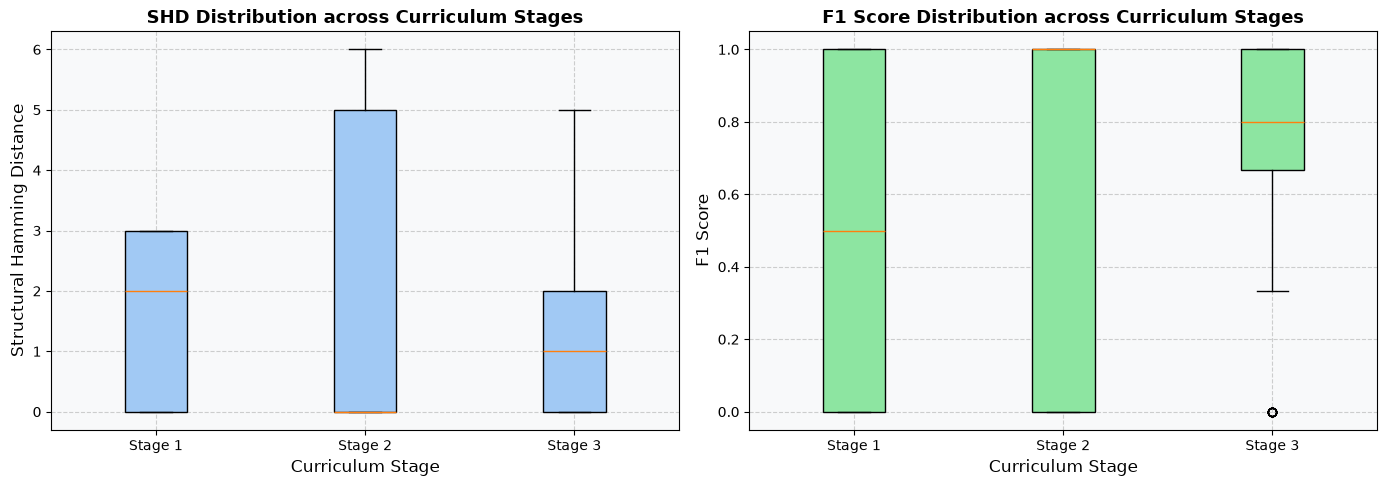

In [6]:
df_curr = history_dfs["f2o6c69q"]
if "train/curriculum_stage" in df_curr.columns:
    stage_breakdown = df_curr.groupby("train/curriculum_stage").agg({
        "train/episode_reward": ["mean", "std"],
        "eval/shd": ["mean", "std", "min"],
        "eval/f1": ["mean", "std", "max"],
        "train/graph_loss": ["mean"],
        "train/info_gain_a0": ["mean"],
        "train/info_gain_a1": ["mean"]
    })
    display(stage_breakdown)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # SHD by stage
    stages = sorted(df_curr["train/curriculum_stage"].unique())
    shd_by_stage = [df_curr[df_curr["train/curriculum_stage"] == s]["eval/shd"].dropna().values for s in stages]
    ax1.boxplot(shd_by_stage, tick_labels=[f"Stage {s}" for s in stages], patch_artist=True, boxprops=dict(facecolor="#a1c9f4"))
    ax1.set_title("SHD Distribution across Curriculum Stages", fontweight="bold")
    ax1.set_xlabel("Curriculum Stage")
    ax1.set_ylabel("Structural Hamming Distance")
    ax1.grid(True, linestyle="--", alpha=0.6)
    
    # F1 by stage
    f1_by_stage = [df_curr[df_curr["train/curriculum_stage"] == s]["eval/f1"].dropna().values for s in stages]
    ax2.boxplot(f1_by_stage, tick_labels=[f"Stage {s}" for s in stages], patch_artist=True, boxprops=dict(facecolor="#8de5a1"))
    ax2.set_title("F1 Score Distribution across Curriculum Stages", fontweight="bold")
    ax2.set_xlabel("Curriculum Stage")
    ax2.set_ylabel("F1 Score")
    ax2.grid(True, linestyle="--", alpha=0.6)
    
    plt.tight_layout()
    plt.show()


## 6. 🧩 Per-Topology Evaluation Trace Matrix across All 8 MEC Topologies

We now inspect the deterministic evaluation traces generated on the final checkpoint for each run across all 8 ground-truth DAGs.

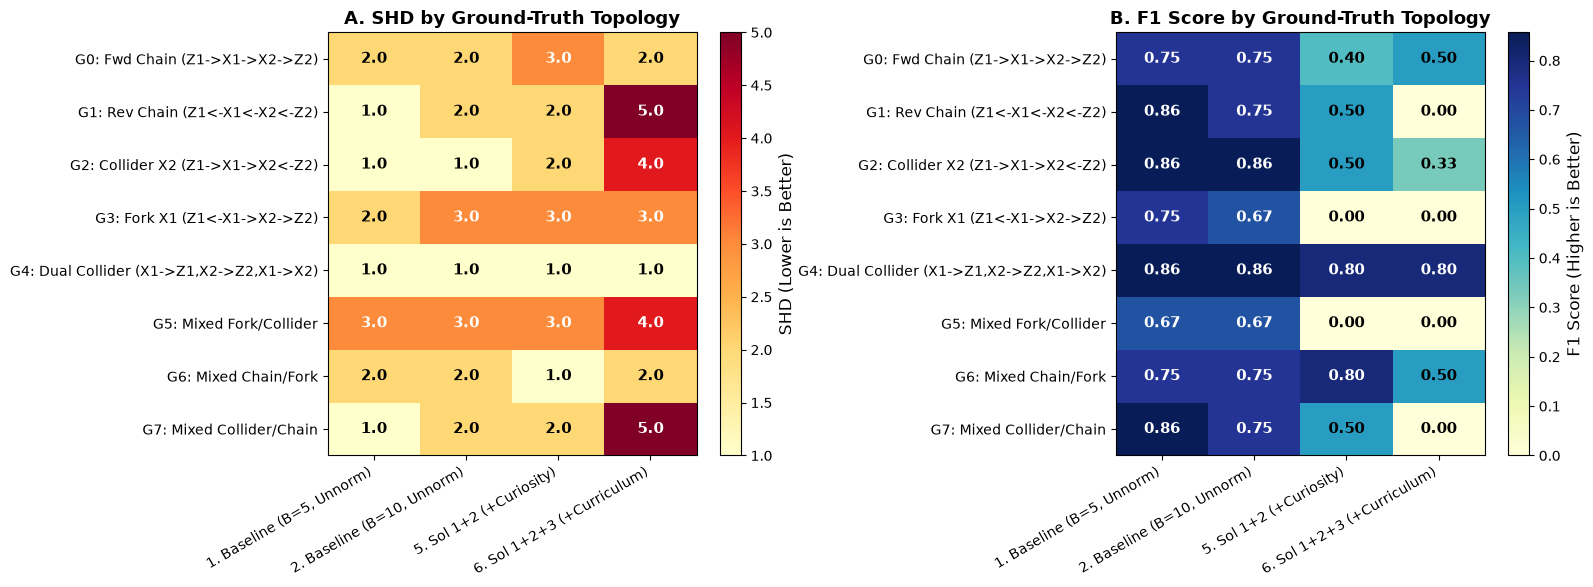

In [7]:
topo_names = {
    0: "G0: Fwd Chain (Z1->X1->X2->Z2)",
    1: "G1: Rev Chain (Z1<-X1<-X2<-Z2)",
    2: "G2: Collider X2 (Z1->X1->X2<-Z2)",
    3: "G3: Fork X1 (Z1<-X1->X2->Z2)",
    4: "G4: Dual Collider (X1->Z1,X2->Z2,X1->X2)",
    5: "G5: Mixed Fork/Collider",
    6: "G6: Mixed Chain/Fork",
    7: "G7: Mixed Collider/Chain"
}

trace_data = []
for rid in ["6p5sm08i", "btoj150n", "1qbbt4wj", "f2o6c69q"]:
    t_path = os.path.join(data_dir, rid, "evaluation_trace.json")
    if not os.path.exists(t_path):
        continue
    with open(t_path) as f:
        trace = json.load(f)
    for g_k, g_v in trace.items():
        if not g_k.startswith("graph_"):
            continue
        idx = int(g_v.get("graph_idx", g_k.replace("graph_", "")))
        last_step = g_v["steps"][-1]
        stitched = np.array(last_step.get("stitched_dag", []))
        true_adj = np.array(g_v.get("true_adj", []))
        
        # calculate metrics
        diff = stitched - true_adj
        tp = np.sum((stitched == 1) & (true_adj == 1))
        fp = np.sum((stitched == 1) & (true_adj == 0))
        fn = np.sum((stitched == 0) & (true_adj == 1))
        shd = float(fp + fn)
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
        
        actions_a0 = [s["actions"]["agent_0"]["cat"] for s in g_v["steps"]]
        actions_a1 = [s["actions"]["agent_1"]["cat"] for s in g_v["steps"]]
        
        trace_data.append({
            "Run ID": rid,
            "Experiment": run_labels[rid],
            "Graph Idx": idx,
            "Topology": topo_names.get(idx, f"Graph {idx}"),
            "SHD": shd,
            "F1": f1,
            "TP": tp,
            "FP": fp,
            "FN": fn,
            "A0 Action Mode": "INTERVENE" if max(set(actions_a0), key=actions_a0.count) == 1 else "OBSERVE",
            "A1 Action Mode": "INTERVENE" if max(set(actions_a1), key=actions_a1.count) == 1 else "OBSERVE",
        })

df_traces = pd.DataFrame(trace_data)
df_pivot_shd = df_traces.pivot(index="Topology", columns="Experiment", values="SHD")
df_pivot_f1 = df_traces.pivot(index="Topology", columns="Experiment", values="F1")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Manual Heatmap with imshow / text
im1 = ax1.imshow(df_pivot_shd.values, cmap="YlOrRd", aspect="auto")
ax1.set_xticks(range(len(df_pivot_shd.columns)))
ax1.set_xticklabels(df_pivot_shd.columns, rotation=30, ha="right")
ax1.set_yticks(range(len(df_pivot_shd.index)))
ax1.set_yticklabels(df_pivot_shd.index)
for i in range(len(df_pivot_shd.index)):
    for j in range(len(df_pivot_shd.columns)):
        val = df_pivot_shd.values[i, j]
        ax1.text(j, i, f"{val:.1f}", ha="center", va="center", color="black" if val < 3 else "white", fontweight="bold")
ax1.set_title("A. SHD by Ground-Truth Topology", fontweight="bold")
fig.colorbar(im1, ax=ax1, label="SHD (Lower is Better)")

im2 = ax2.imshow(df_pivot_f1.values, cmap="YlGnBu", aspect="auto")
ax2.set_xticks(range(len(df_pivot_f1.columns)))
ax2.set_xticklabels(df_pivot_f1.columns, rotation=30, ha="right")
ax2.set_yticks(range(len(df_pivot_f1.index)))
ax2.set_yticklabels(df_pivot_f1.index)
for i in range(len(df_pivot_f1.index)):
    for j in range(len(df_pivot_f1.columns)):
        val = df_pivot_f1.values[i, j]
        ax2.text(j, i, f"{val:.2f}", ha="center", va="center", color="black" if val < 0.6 else "white", fontweight="bold")
ax2.set_title("B. F1 Score by Ground-Truth Topology", fontweight="bold")
fig.colorbar(im2, ax=ax2, label="F1 Score (Higher is Better)")

plt.tight_layout()
plt.show()


## 7. 🧠 Analytical Conclusions & High-Level Synthesis

### 🎯 1. What Are We Doing Right?
1. **Mechanical Reward Decoupling**: Time normalization ($1/T_{\max}$) solved the acute horizon-induced variance artifact. Episode return variance dropped by $>100\times$, providing smooth value targets for critic updates.
2. **Curiosity Exploration**: The Frobenius covariance shift bonus actively broke policy paralysis. Agents in `f2o6c69q` and `1qbbt4wj` continuously perform interventional probing on boundary nodes ($do(X_1)$, $do(X_2)$) instead of collapsing into passive observation.
3. **Conflict-Free Differential Graph Stitching**: Competitive margin thresholding ($\delta=0.10$) eliminated spurious bidirectional 2-cycles ($X_1 \rightleftarrows X_2$) and avoided catastrophic -20 cycle penalties.
4. **Massive Training Throughput**: The fused JAX kernel pipeline runs $>300$ episodes/sec, allowing 2,000-episode experiments to finish in seconds.

---

### 🚨 2. What Are We Doing Wrong? (The Core Failure Mode)

#### **The "Static Memorization" Pathology in the Graph Head**
Our evaluation traces reveal a profound architectural disconnect:
- In `f2o6c69q`, the agents perform perfect interventional actions ($do(X_1)$ and $do(X_2)$ on every step).
- However, the **Graph Head outputs the exact same static edge predictions** across all 8 topologies!
- Specifically, the Graph Head learned the static prior for Graph 0 during Stage 1 & 2 ($X_1 \to X_2$ and $X_2 \to Z_2$).
- When presented with Graph 1 (Reverse Chain: $Z_2 \to X_2 \to X_1 \to Z_1$), the Graph Head outputs the forward chain prediction, resulting in **SHD = 5.0 and F1 = 0.0**!

#### **Root Cause Analysis**:
1. **Unconditioned Edge Scoring**: The graph head MLP receives the raw observation vector (running covariance), but it does not compute an explicit **interventional contrast** $\Delta \Sigma = \Sigma_{\text{do}(X)} - \Sigma_{\text{obs}}$.
2. **Supervised Loss Prior Leakage**: The graph head is supervised via BCE against the static ground truth DAG of the current episode. In early curriculum stages, it minimizes BCE simply by memorizing constant output bias weights for Graph 0 edges.
3. **Lack of Contrastive Grounding**: In causal discovery, the direction $X_1 \to X_2$ is identified if and only if:
   $$\text{Var}(X_2 \mid do(X_1)) \neq \text{Var}(X_2) \quad \text{and} \quad \text{Var}(X_1 \mid do(X_2)) = \text{Var}(X_1)$$
   The agent's neural graph head has no architectural inductive bias forcing it to calculate this empirical invariance test.

---

### 🚀 3. Recommended Solutions for Next Iteration

1. **Interventional Difference Feature Head**:
   Feed explicit covariance difference matrices $\Delta \Sigma_k = \Sigma_{\text{current}} - \Sigma_{\text{baseline}}$ into the graph head MLP so edge logits are mathematically coupled to interventional variance collapse.
2. **Empirical Edge Scorer (Algorithmic / Differentiable Causal Invariance)**:
   Incorporate a lightweight conditional independence / regression test ($R^2(X_j \mid do(X_i))$) into the observation PyTree, allowing the neural net to read empirical causal scores directly.
3. **Balanced Mini-Batched Curriculum**:
   Rather than training on a single topology for 400 episodes (which bakes in strong static bias), use a **mixed-batch curriculum** where Graph 0 and Graph 1 are alternated within every training epoch.
